In [1]:
import math
import random

In [27]:
class Value:
    
    def __init__(self,data,_children = (), _op = "",label = ""):
        self.data = data
        self._prev = set(_children)
        self.label = label
        self._op = _op
        self.grad = 0
        self._backward = lambda: None
    
    def __repr__(self):
        return f"Value(data = {self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        sum = Value(self.data + other.data,(self,other), "+")
        def _backward():
            self.grad += 1.0*sum.grad
            other.grad += 1.0*sum.grad
        sum._backward = _backward
        return sum  
    
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        product = Value(self.data * other.data,(self,other), "*")
        def _backward():
            self.grad += other.data * product.grad
            other.grad += self.data * product.grad
        product._backward = _backward
        return product 
    
    def __rmul__(self,other):
        return self*other 
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n)+1)
        out = Value(t,(self,),"tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,) ,"exp")
        def _backward():
            self.grad = out.data * out.grad
        out._backward = _backward
        return out

    def __truediv__(self,other):
        return self*other**-1
    
    def __neg__(self): 

        return self * -1

    def __sub__(self, other): 
        return self + (-other)

    def __radd__(self, other): 
        return self + other
    
    def __pow__(self,other):
        assert isinstance(other,(int,float))
        out = Value(self.data**other,(self,),f"**{other}")
        def _backward():
            self.grad = ((self.data**(other-1))*(other)) * out.grad
        out._backward = _backward
        return out
    def backward(self):
        topo = []
        visited = set()
        def topo_sort(v):
            if v not in visited:
                visited.add(v)
                for c in v._prev:
                    topo_sort(c)
                topo.append(v)
        topo_sort(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

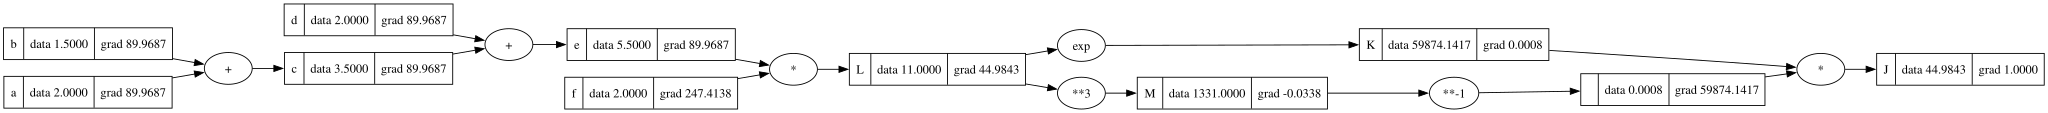

In [22]:
a = Value(2.0,label = "a")
b = Value(1.5,label = "b")
c = a+b
c.label = "c"
d = Value(2.0);d.label = "d"
e = c + d
e.label = "e"
f = Value(2.0,label = "f")
L = e*f;L.label = "L"
K = L.exp();K.label = "K"
M = L**3;M.label = 'M'
J = K/M ; J.label = "J"
J.backward()
draw_dot(J)


In [34]:
class Neuron:

    def __init__(self,nin):
        self.w = [Value(random.uniform(1,-1)) for _ in range(nin)]
        self.b = Value(random.uniform(1,-1))

    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    
    def __init__(self,nin,nout):

        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
x = [4,5,6,1,2]
n = MLP(4,[4,4,3,2,1])
n(x)



Value(data = -0.22049620065499922)

0 0.15206034379918118
1 0.1518815688461594
2 0.15170815228165546
3 0.1515398530597009
4 0.15137644452677523
5 0.15121771335554707
6 0.15106345857254472
7 0.15091349067019907
8 0.1507676307948041
9 0.15062571000289665
10 0.15048756857939533
11 0.15035305541157148
12 0.15022202741356733
13 0.15009434899674487
14 0.14996989158164503
15 0.14984853314777682
16 0.14973015781784632
17 0.1496146554733766
18 0.14950192139897844
19 0.1493918559528005


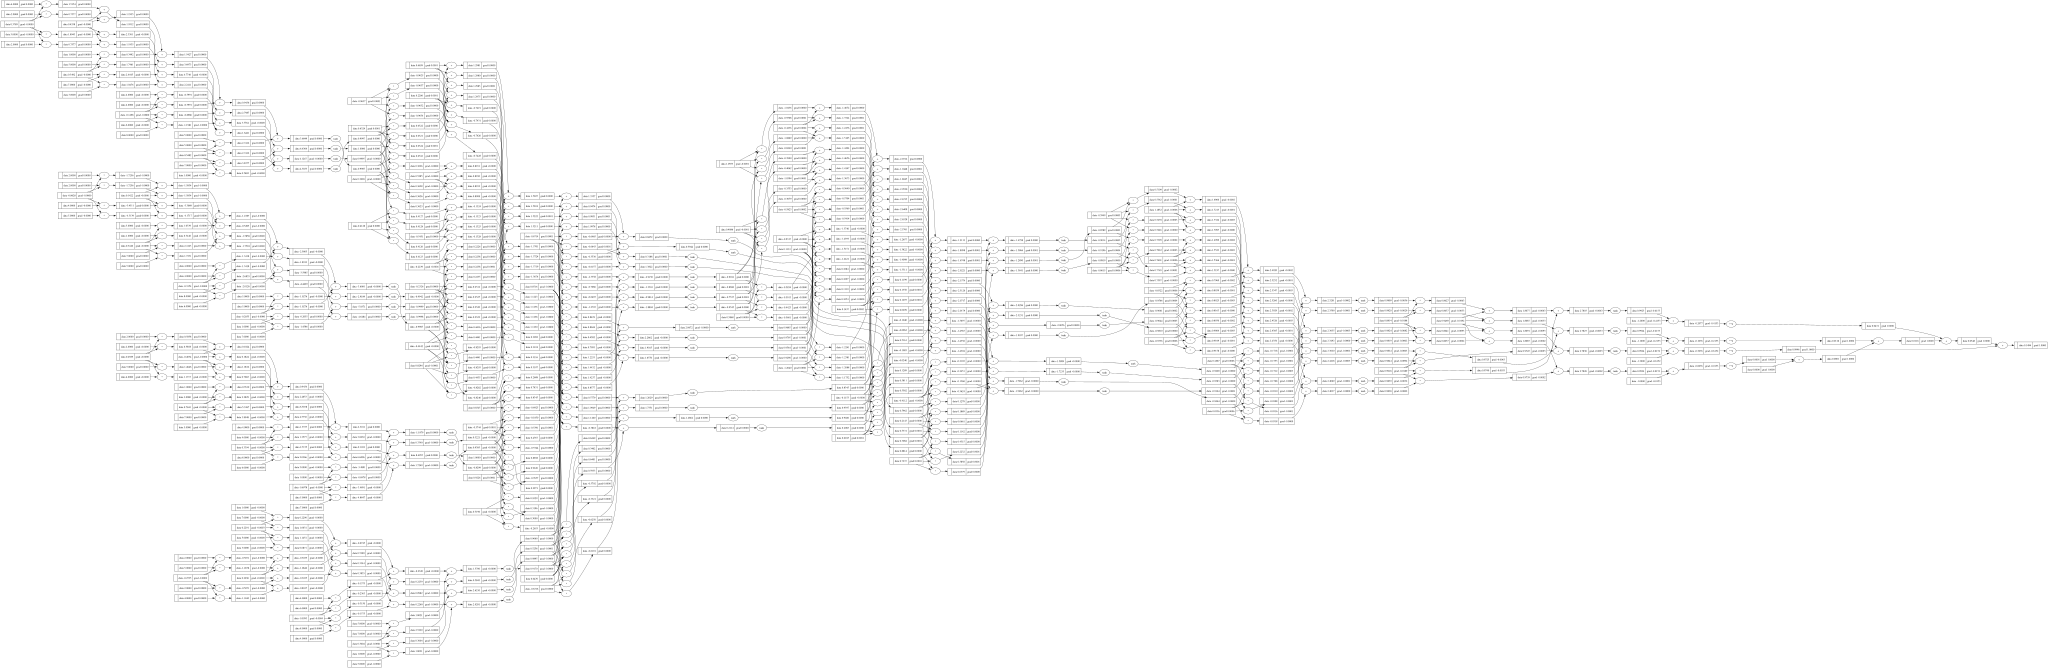

In [37]:
xs = [[2,1,4,5],
      [2,3,4,5],
      [5,7,8,1],
      [4,5,6,7]]

actual = [1,1.1,1.2,1.3]
for k in range(20):

  ys = [n(x) for x in xs]
  loss = sum((pre-ac)**2 for ac,pre in zip(actual,ys))
  
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)
draw_dot(loss)
